# Exercise 2: Memory & Perplexity: KSW Solution

> **Importing Core Libraries for Model Evaluation**

This cell imports the essential libraries and modules needed for the experiments.

**What to check:**

- `math` for mathematical operations.
- `torch` for deep learning and tensor operations.
- `AutoTokenizer` and `AutoModelForCausalLM` from `transformers` for model and tokenizer loading.

In [1]:
import math
import time
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import Dict, Iterable, Callable, Tuple

> **Model Selection: Choosing the LLM for Experiments**

This cell specifies the model name to be used throughout the notebook. The chosen model should be small enough to run on limited hardware but representative for scaling experiments.

**What to check:**

- Assign a string with the Hugging Face model name (e.g., `'TinyLlama/TinyLlama-1.1B-Chat-v1.0'`) to a variable like `MODEL_NAME`.

In [2]:
# ─── SETTINGS ────────────────────────────────────────────────────────────────
# MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
# MODEL_NAME = "HuggingFaceTB/SmolLM2-135M-Instruct"
MODEL_NAME = "facebook/opt-125m"
# MODEL_NAME = "unsloth/LFM2-700M"

> **Model and Tokenizer Loader: Device and Precision Handling**

This function loads the model and tokenizer, moves the model to the correct device (GPU if available, otherwise CPU), and sets the appropriate numerical precision. The model is set to evaluation mode.

**What to implement:**

- Detect if CUDA (GPU) is available and set the device accordingly.
- Choose `torch.float16` if using CUDA, otherwise use `torch.float32`.
- Load the tokenizer and model from the specified model name.
- Move the model to the selected device and set it to evaluation mode.
- Return the tokenizer, model, and device.

In [3]:
def load_model_and_tokenizer(model_name: str):
    """
    TODO:
      - Load tokenizer & model from `model_name`
      - Move model to GPU if available, choose float16 for CUDA else float32
      - Set model to eval mode
      - Return (tokenizer, model, device)
    """
    device_name = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device_name)
    dtype = torch.float16 if device == "cuda" else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype
    )
    model.to(device)
    model.eval()
    return tokenizer, model, device

> **Text Selection: Providing a Sample Passage**

This function returns a sample passage of about 100 tokens, ideally from Wikipedia or a similar source. This passage will be used as the input prompt for all experiments.

**What to implement:**

- Choose or paste a paragraph of about 100 tokens.
- Return the text as a string.

In [4]:
def select_text():
    """
    TODO:
      - Pick or paste a ~100-token passage (e.g. a Wiki snippet)
      - Return (text_str)
    """
    return """
Artificial intelligence (AI) is intelligence demonstrated by machines, in contrast to the natural
intelligence displayed by humans and animals. Leading AI textbooks define the field as the study
of intelligent agents: any system that perceives its environment and takes actions that maximize
its chance of achieving its goals. Colloquially, the term "artificial intelligence" is often
used to describe machines that mimic cognitive functions that humans associate with the human mind,
such as learning and problem-solving.
"""

> **Tokenization with Labels: Preparing Model Inputs**

This function tokenizes the selected text and prepares the input tensors for the model, including setting up the labels for language modeling.

**What to implement:**

- Tokenize the text using the provided tokenizer with `return_tensors='pt'`.
- Set `labels = input_ids` in the returned dictionary.
- Return the inputs dictionary and the input length (number of tokens).

In [5]:
def tokenize_with_labels(tokenizer, text: str):
    """
    TODO:
      - Tokenize `text` with return_tensors="pt"
      - Prepare inputs and set labels = input_ids
      - Return (inputs_dict, input_len)
    """
    inputs = tokenizer(text, return_tensors="pt")
    inputs["labels"] = inputs["input_ids"].clone()
    input_len = inputs["input_ids"].size(1)
    return inputs, input_len

> **Peak Memory and Loss Calculation: Measuring Resource Usage**

This function runs a forward pass of the model on the provided inputs and measures the peak GPU memory usage (if CUDA is available) and the loss value.

**What to implement:**

- If using CUDA, reset peak memory stats before running the model.
- Run the model in `torch.no_grad()` mode to avoid gradient computation.
- After the forward pass, if using CUDA, synchronize and get the peak memory allocated (in MiB).
- Return the peak memory (MiB) and the loss value.

In [6]:
def compute_peak_memory_and_loss(model, inputs, device):
    """
    TODO:
      - Reset peak memory stats if CUDA
      - Run model(**inputs) under torch.no_grad()
      - Sync CUDA if needed
      - Retrieve peak memory via torch.cuda.max_memory_allocated (in MiB)
      - Return (peak_mem_mib, loss_value)
    """
    torch.cuda.reset_peak_memory_stats(device)
    with torch.no_grad():
        outputs = model(
            input_ids=inputs["input_ids"].to(device),
            attention_mask=inputs.get("attention_mask", None).to(device) if inputs.get("attention_mask") is not None else None,
            labels=inputs["labels"].to(device)
        )
    if device.type == "cuda":
        torch.cuda.synchronize()
        peak_bytes = torch.cuda.max_memory_allocated(device)
        peak_mib = peak_bytes / 1024**2
    else:
        peak_mib = float("nan")
    return peak_mib, outputs.loss.item()

> **Perplexity Computation: Interpreting Model Loss**

This function converts the model's loss value into perplexity, a standard metric for evaluating language models.

**What to implement:**

- Use `math.exp(loss)` to compute perplexity from the loss value.
- Return the perplexity.

In [7]:
def compute_perplexity(loss: float):
    """
    TODO:
      - Compute and return math.exp(loss)
    """
    return math.exp(loss)

> **Forward Pass Timing: Measuring Inference Latency**

This function measures the average time taken for the model to perform a forward pass (inference) on the input data. It includes warmup runs to stabilize performance and reports the mean latency over several timed runs.

Note: 
- time_forward measures the latency for a forward pas
- It does not measure the latancy for token generation.
- Hence use model(**inputs_on_device). Don't use model.generate(input_ids) in this case

In [8]:
def time_forward(model, inputs: Dict[str, torch.Tensor], device, num_warmup: int = 1, num_runs: int = 3):
    """
    TODO:
      1) Move all tensors in `inputs` to `device`.
      2) Warmup (no timing): under torch.no_grad(), run a small number of forward passes
         (num_warmup times) to stabilize kernels/clocks:
             _ = model(**inputs_on_device)
         If CUDA, call torch.cuda.synchronize() after warmup.
      3) Timed runs: create an empty list `latencies = []`.
         For _ in range(num_runs):
           - Record start time with time.perf_counter()
           - Under torch.no_grad(), run a forward pass:
                 _ = model(**inputs_on_device)
           - If CUDA, call torch.cuda.synchronize()
           - Record end time with time.perf_counter()
           - Append (end - start) to `latencies`.
      4) Return the average latency in seconds:
             return sum(latencies) / max(len(latencies), 1)
    """

    # 1. Move tensors in inputs to device
    inputs_on_device = {k: v.to(device) for k, v in inputs.items()}

    # 2. Warmup
    with torch.no_grad():
        for _ in range(num_warmup):
            _ = model(**inputs_on_device)

    # 3. Timed runs
    latencies = []
    if device.type == "cuda": 
        torch.cuda.synchronize()
    with torch.no_grad():
        for _ in range(num_runs):
            start = time.perf_counter()
            _ = model(**inputs_on_device)
            if device.type == "cuda": 
                torch.cuda.synchronize()
            end = time.perf_counter()
            latencies.append(end-start)
            

    # 4. Average Latencies
    average_latency = sum(latencies)/ max(len(latencies), 1)     
    
    return average_latency

> **Context Length Sweep: Scaling Analysis with Input Size**

This function systematically increases the input (context) length and measures how peak memory usage and inference latency scale. It builds longer input texts, runs the model, and visualizes the results.

**What to implement:**

- Determine the model's maximum context length from `model.config` (default to 2048 if unavailable).

- Filter the target context lengths to those that fit within the model's window.
- Build input texts of increasing length by repeating the base passage.
- For each target length:

  - Tokenize and prepare inputs.
  - Move tensors to the correct device.
  - Measure peak memory and latency using the functions above.
  - Print a summary for each run.
- Plot memory and latency vs. input length using matplotlib.
- Return a dictionary with the results.

In [9]:
import matplotlib.pyplot as plt

def sweep_context_length(
    tokenizer,
    model,
    device,
    targets=(64, 256, 1024),
    base_text=None,
    build_text_fn=None,
    warmup=1,
    runs=3,
    plot=True,
):
    """
    TODO:
      1) Determine the model's maximum context length:
         - Read `max_position_embeddings` from `model.config` (fallback to 2048).
         - Filter `targets` to those <= `max_len - 2` (leave room for special tokens).
         - If no valid targets remain, raise a ValueError.

      2) Choose a base paragraph:
         - If `base_text` is None, call `select_text()`; if unavailable, raise with a helpful message.

      3) Build texts of desired token lengths:
         - Implement a builder that repeats `base_text` until the tokenized length >= `target_tokens`.
         - Allow overriding via `build_text_fn(tokenizer, base_text, target_tokens)`.

      4) For each target length:
         - Build the text and tokenize with `tokenize_with_labels(tokenizer, text)` to get `(inputs, input_len)`.
         - Move all tensors in `inputs` to `device`.
         - Compute peak memory (MiB) and loss using `compute_peak_memory_and_loss(model, inputs, device)`.
         - Measure forward (prefill) latency using `time_forward(model, inputs, device, num_warmup=warmup, num_runs=runs)`.
         - Append `input_len`, `peak_mib`, and `latency_s` to running lists.
         - Print a concise summary line for each target.

      5) If `plot` is True, create two matplotlib plots (one per figure):
         - Peak memory (MiB) vs input tokens.
         - Forward latency (s) vs input tokens.
         - Use simple line plots with markers and grid; do not specify custom colors.

      6) Return a results dictionary with:
         - 'lengths': list of actual input token counts
         - 'peak_mib': list of peak memory values (MiB)
         - 'latency_s': list of forward latencies (s)
         - 'max_ctx': the model’s max context length
         - 'targets_used': the filtered list of targets
    """

    print(model.config)

    # 2. Choose a base paragraph
    if base_text is None:
        base_text = select_text()

    # 3. Build Texts of Desired Token Lengths
    raise NotImplementedError

> **Precision Comparison: Memory and Perplexity Across dtypes**

This function compares the model's memory usage and perplexity when run with different numerical precisions (float16 and float32). It reloads the model for each precision, runs evaluation, and summarizes the trade-offs.

**What to implement:**

- Prepare a short evaluation paragraph (use the text selection function).

- Tokenize the text once for all precisions.
- For each precision:

  - Reload the model and tokenizer with the correct dtype.
  - Move inputs to the correct device.
  - Measure peak memory and loss, then compute perplexity.
  - Store results in a dictionary.
- Return the results dictionary.

In [10]:

def sweep_precision(
    model_name: str,
    tokenizer,
    load_with_dtype_fn: Callable[[str], Tuple],  # returns (tokenizer, model, device)
    precisions: Iterable[str] = ("float16", "float32"),
    base_text: str = None,
    target_len: int = 128,
    num_warmup: int = 5,
    num_runs: int = 10,
    plot: bool = True,
    use_model_generate = True,
) -> Dict[str, Dict[str, float]]:
    """
    Sweep model precisions and record peak memory, perplexity, latency, and throughput.

    Returns:
        dict keyed by precision:
            {
                "float16": {"peak_mib": ..., "ppl": ..., "latency_s": ..., "throughput_tokens_per_s": ...},
                "float32": {...}
            }
    """
    if base_text is None:
        base_text = select_text()

    # Tokenize once
    inputs, _ = tokenize_with_labels(tokenizer, base_text)
    
    # Lists to store metric values
    peak_mibs = []
    perplexitys = []
    latencies = []
    throughputs = []
    target_lens = []

    for precision in precisions:
        # Reload model with the given dtype
        tok_p, mod_p, dev_p = load_with_dtype_fn(precision)

        # Move inputs to correct device
        inputs_on_device = {k: v.to(dev_p) for k, v in inputs.items()}
        input_ids_on_device = inputs_on_device["input_ids"]

        # 1. Peak memory + loss
        peak_mib, loss_val = compute_peak_memory_and_loss(mod_p, inputs_on_device, dev_p)
        peak_mibs.append(peak_mib)

        # 2. Perplexity
        ppl = compute_perplexity(loss_val)
        perplexitys.append(ppl)

        # 3. Latency (average over num_runs)
        batch_latencies = []
        with torch.no_grad():
            # Warmup
            for _ in range(num_warmup):
                _ = mod_p(**inputs_on_device)
                if dev_p.type == "cuda":
                    torch.cuda.synchronize()

            # Timed runs
            for _ in range(num_runs):
                start = time.perf_counter()
                # _ = mod_p(**inputs_on_device)
                _ = mod_p.generate(input_ids_on_device, max_new_tokens=50, use_cache=True)
                if dev_p.type == "cuda":
                    torch.cuda.synchronize()
                end = time.perf_counter()
                batch_latencies.append(end - start)

        avg_latency = sum(batch_latencies) / len(batch_latencies)
        latencies.append(avg_latency)

        # 4. Throughput (tokens/sec)
        seq_len = inputs_on_device["input_ids"].shape[1]
        batch_size = inputs_on_device["input_ids"].shape[0]
        total_tokens = batch_size * seq_len
        throughput = total_tokens / avg_latency
        throughputs.append(throughput)

        target_lens.append(target_len)

        # Print summary
        print(f"Precision {precision}: peak={peak_mib:.1f} MiB | ppl={ppl:.3f} | "
              f"latency={avg_latency:.3f}s | throughput={throughput:.1f} tok/s")

    # 5. Pack results into a dict
    results = {
        "precision": list(precisions),
        "peak_mib": peak_mibs,
        "perplexity": perplexitys,
        "latency_s": latencies,
        "throughput_tokens_per_s": throughputs,
        "target_len": target_lens,
    }

    # 6. Plot metrics in a loop
    if plot:
        metrics = ["peak_mib", "perplexity", "latency_s", "throughput_tokens_per_s"]
        titles = ["Peak Memory (MiB)", "Perplexity", "Latency (s)", "Throughput (tokens/sec)"]

        fig, axes = plt.subplots(2, 2, figsize=(15, 8))
        axes = axes.flatten()  # flatten 2x2 array to 1D for looping

        for i, metric in enumerate(metrics):
            axes[i].plot(results["precision"], results[metric], marker='o')
            axes[i].set_title(titles[i])
            axes[i].set_xlabel("Precision")
            axes[i].set_ylabel(titles[i])
            axes[i].grid(True)

        plt.tight_layout()
        plt.show()

    return results

> **Batch Size Sweep: Analyzing Memory Scaling with Batch Size**

This function evaluates how peak memory usage changes as the batch size increases. It creates batches of repeated input text, runs the model, and plots the relationship between batch size and memory consumption.

**What to implement:**

- Prepare a base paragraph for batching.
- For each batch size:

  - Create a batch of repeated texts and tokenize with padding and truncation.
  - Move tensors to the correct device.
  - Measure peak memory using the earlier function.
  - Print a summary for each batch size.
- Plot memory vs. batch size using matplotlib.
- Return a dictionary with the results.

In [11]:
def build_batched_inputs(tokenizer, text, batch_size, max_seq_len):
    """
    Build a batch of identical tokenized inputs for language modeling.

    Args:
        tokenizer: HuggingFace tokenizer
        text (str): input text
        batch_size (int): batch size
        max_seq_len (int): maximum sequence length

    Returns:
        dict: tokenized batch with labels
    """

    # Repeat the same text bs times
    texts = [text] * batch_size

    # Tokenize
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding="longest",
        truncation=True,
        max_length=max_seq_len
    )

    # Labels for causal LM = input_ids
    inputs["labels"] = inputs["input_ids"].clone()

    return inputs

def sweep_batch_size(
    tokenizer,
    model,
    device,
    batch_sizes=(1, 2, 4),
    base_text=None,
    target_len=128,
    plot=True,
    num_warmup = 5,
    num_runs=10,  # Number of forward passes to average latency
):
    """
    TODO:
      1) Choose a base paragraph:
         - If `base_text` is None, call `select_text()` to get a default paragraph.

      2) Implement a helper to build batched inputs:
         - Given (tokenizer, text, bs, max_len), tokenize a list of the same `text`
           repeated `bs` times with:
               return_tensors='pt', padding='longest', truncation=True, max_length=target_len
         - Set enc['labels'] = enc['input_ids'].clone()

      3) For each batch size in `batch_sizes`:
         - Build the batch with the helper.
         - Move all tensors to `device`.
         - Measure peak memory (MiB) using `compute_peak_memory_and_loss(model, enc, device)`.
         - Record (bs, peak_mib) and print a concise summary line.

      4) If `plot` is True, produce a single matplotlib figure of:
         - x = batch size
         - y = peak MiB
         - Use a simple line plot with markers and grid; do not set custom colors.

      5) Return a results dictionary:
         {
           "batch_sizes": [...],
           "peak_mib": [...],
           "target_len": target_len,
         }

     6) Other additions as deemed appropriate by KSW
    """
    if base_text is None:
        base_text = select_text()

    peak_mibs = []
    perplexitys = []
    target_lens = []
    latencies = []
    throughputs = []

    for batch_size in batch_sizes:
        # Build batch
        inputs = build_batched_inputs(tokenizer, base_text, batch_size, target_len)
        inputs_on_device = {k: v.to(device) for k, v in inputs.items()}

        # 1. Peak memory + loss
        peak_mib, loss_val = compute_peak_memory_and_loss(model, inputs_on_device, device)
        peak_mibs.append(peak_mib)

        # 2. Perplexity
        ppl = compute_perplexity(loss_val)
        perplexitys.append(ppl)

        # 3. Latency (average over num_runs)
        batch_latencies = []
        with torch.no_grad():
            # Warmup
            for _ in range(num_warmup):
                _ = model(**inputs_on_device)
                if device.type == "cuda":
                    torch.cuda.synchronize()

            # Timed runs
            for _ in range(num_runs):
                start = time.perf_counter()
                _ = model(**inputs_on_device)
                if device.type == "cuda":
                    torch.cuda.synchronize()
                end = time.perf_counter()
                batch_latencies.append(end - start)

        avg_latency = sum(batch_latencies) / len(batch_latencies)
        latencies.append(avg_latency)

        # 4. Throughput: (batch_size * seq_len) / latency
        # Note : batch_size = inputs_on_device["input_ids"].shape[0]
        
        seq_len = inputs_on_device["input_ids"].shape[1]
        total_num_tokens = batch_size * seq_len
        throughput = total_num_tokens/ avg_latency
        throughputs.append(throughput)

        target_lens.append(target_len)

        # Print summary line
        print(f"Batch {batch_size}: peak={peak_mib:.1f} MiB | perplxity={ppl:.3f} | "
              f"latency={avg_latency:.3f}s | throughput={throughput:.1f} tok/s")

    # 5. Results dictionary
    results = {
        "batch_sizes": batch_sizes,
        "peak_mib": peak_mibs,
        "perplexity": perplexitys,
        "latency_s": latencies,
        "throughput_tokens_per_s": throughputs,
        "target_len": target_lens,
    }
    
    # 6. Plot results
    if plot:
        metrics = ["peak_mib", "perplexity", "latency_s", "throughput_tokens_per_s"]
        titles = ["Peak Memory (MiB)", "Perplexity", "Latency (s)", "Throughput (tokens/sec)"]
    
        fig, axes = plt.subplots(2, 2, figsize=(15, 8))
        axes = axes.flatten()  # flatten to 1D array for easy looping
    
        for i, metric in enumerate(metrics):
            axes[i].plot(batch_sizes, results[metric], marker='o')
            axes[i].set_title(titles[i])
            axes[i].set_xlabel("Batch Size")
            axes[i].set_ylabel(titles[i])
            axes[i].grid(True)
    
        plt.tight_layout()
        plt.show()
            
    return results

> **Experiment Runner: Orchestrating All Analyses**

This function coordinates the entire experiment workflow. It loads the model and tokenizer, prepares the input, runs baseline measurements, and then executes the context length sweep, precision comparison, and batch size sweep. The results are returned in a structured dictionary for further analysis or reporting.

**What to implement:**

- Load the model and tokenizer using your loader function.
- Select and tokenize a baseline paragraph.
- Run baseline measurements: peak memory, loss, perplexity, and forward latency.
- Run the context length sweep, precision comparison, and batch size sweep functions.
- Return a dictionary with all results.

In [12]:
def start():
    if "load_with_dtype" not in globals():
        def load_with_dtype(dtype_str: str):
            tok_p, mod_p, dev_p = load_model_and_tokenizer(MODEL_NAME)
            return tok_p, mod_p, dev_p


    # --- 1) Load model/tokenizer ---
    tokenizer, model, device = load_model_and_tokenizer(MODEL_NAME)
    print(f"[load] device={device}")

    # --- 2) Select & tokenize a baseline paragraph ---
    text = select_text()
    inputs, input_len = tokenize_with_labels(tokenizer, text)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    print(f"[tokenize] tokens={input_len}")

    # --- 3) Baseline: peak memory & loss ---
    peak_mib, loss = compute_peak_memory_and_loss(model, inputs, device)
    ppl = compute_perplexity(loss)
    fwd_lat = time_forward(model, inputs, device)
    print(f"[baseline] peak={peak_mib:.1f} MiB | loss={loss:.3f} | ppl={ppl:.3f} | fwd={fwd_lat:.3f}s")

    '''
    # --- A) Context-length sweep ---
    ctx_results = sweep_context_length(
        tokenizer=tokenizer,
        model=model,
        device=device,
    )
    '''

    # --- B) Precision comparison ---
    prec_results = sweep_precision(
        model_name=MODEL_NAME,
        tokenizer=tokenizer,
        load_with_dtype_fn=load_with_dtype,
        precisions=("float16", "float32"),
        base_text=text,
    )

    # --- C) Batch-size sweep ---
    batch_results = sweep_batch_size(
        tokenizer=tokenizer,
        model=model,
        device=device,
    )

    return {
        "baseline": {
            "tokens": int(input_len),
            "peak_mib": float(peak_mib),
            "loss": float(loss),
            "ppl": float(ppl),
            "forward_latency_s": float(fwd_lat),
        },
        # "context_sweep": ctx_results,
        "precision_compare": prec_results,
        "batch_sweep": batch_results,
    }


[load] device=cuda
[tokenize] tokens=102
[baseline] peak=534.6 MiB | loss=2.879 | ppl=17.799 | fwd=0.011s
Precision float16: peak=1014.2 MiB | ppl=17.799 | latency=0.200s | throughput=509.5 tok/s
Precision float32: peak=1013.5 MiB | ppl=17.799 | latency=0.198s | throughput=515.2 tok/s


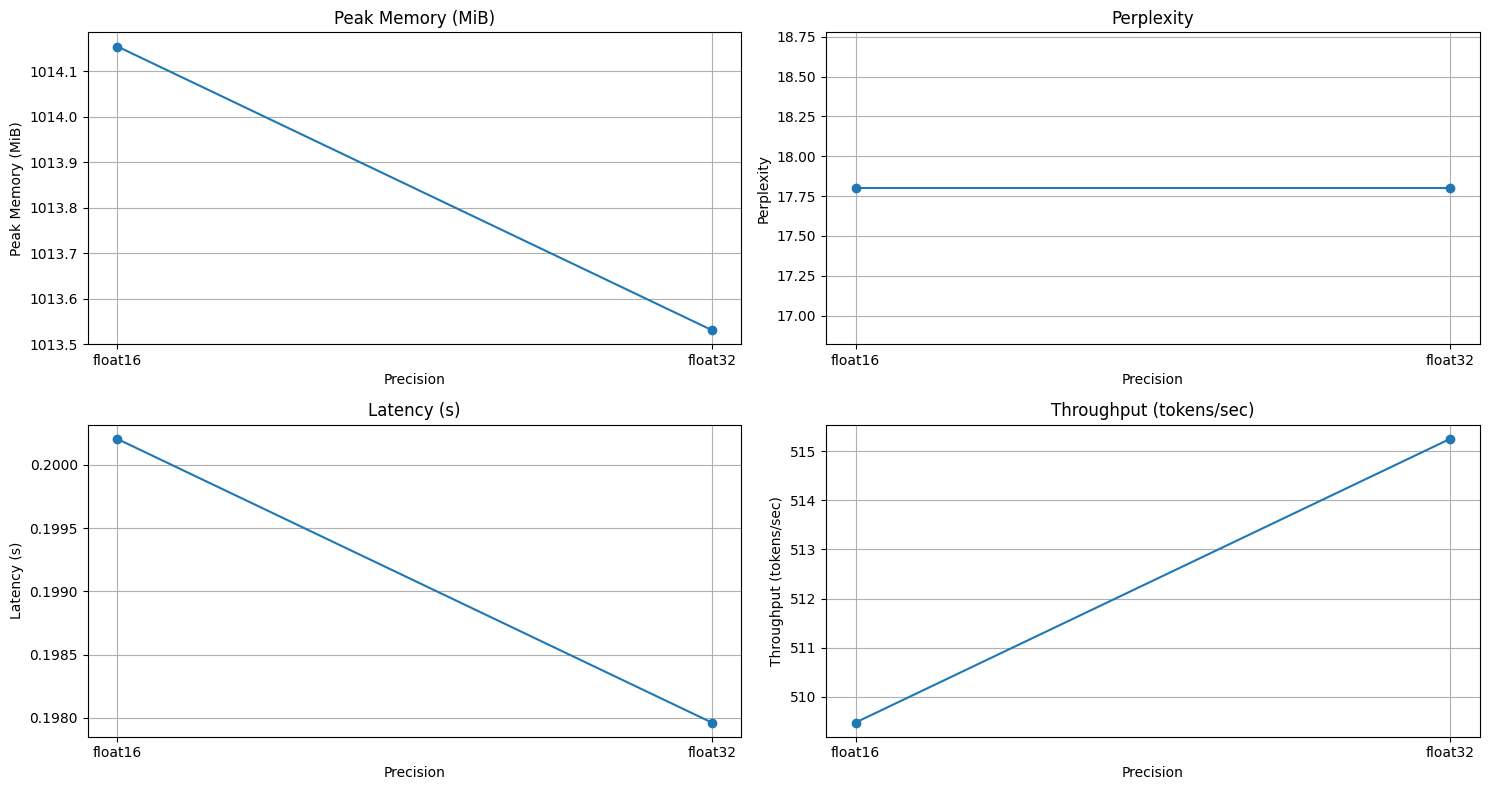

Batch 1: peak=534.6 MiB | perplxity=17.799 | latency=0.011s | throughput=9627.6 tok/s
Batch 2: peak=607.5 MiB | perplxity=17.799 | latency=0.017s | throughput=11889.3 tok/s
Batch 4: peak=738.7 MiB | perplxity=17.799 | latency=0.031s | throughput=13138.9 tok/s


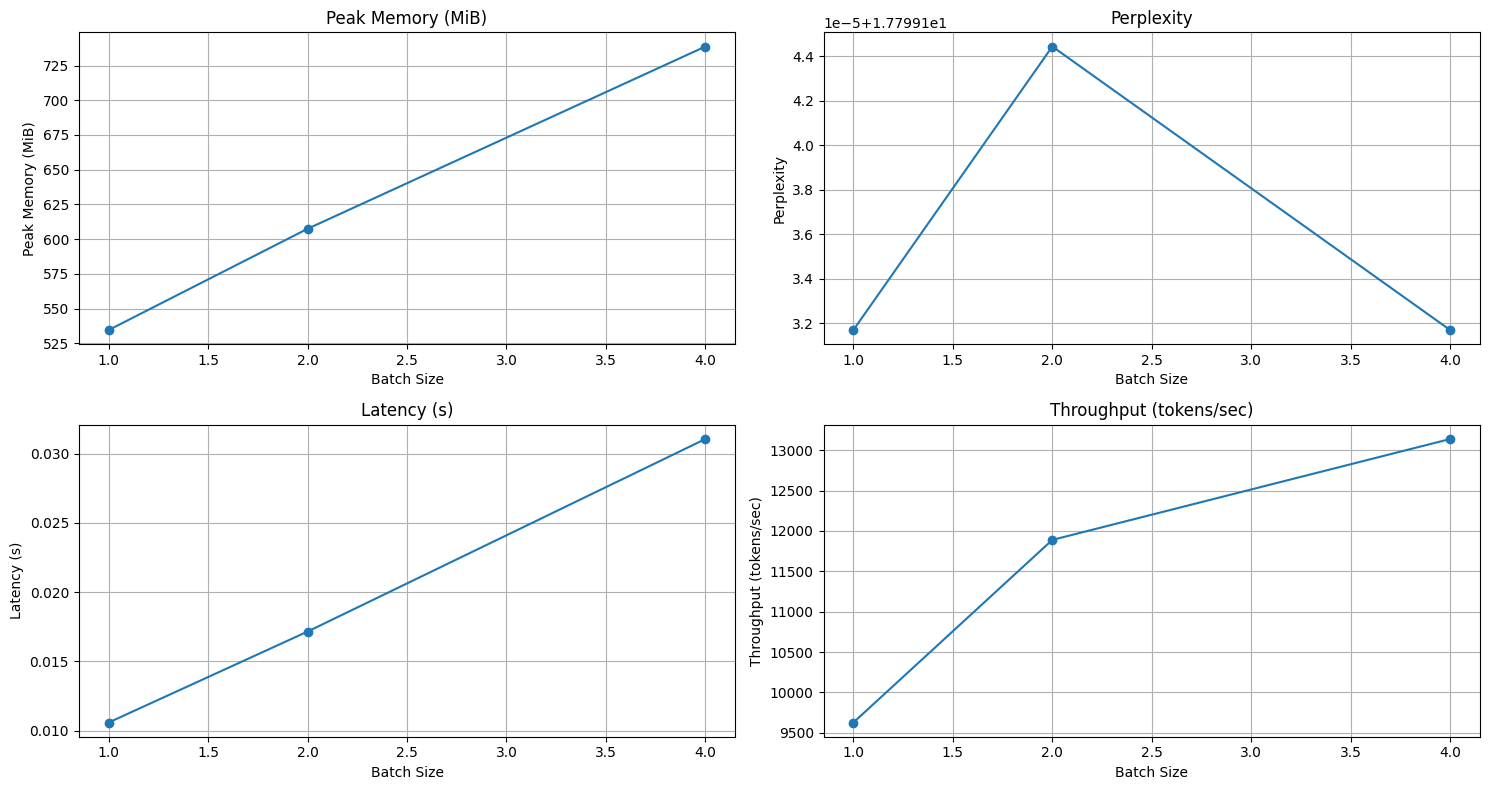

{'baseline': {'tokens': 102,
  'peak_mib': 534.5634765625,
  'loss': 2.8791496753692627,
  'ppl': 17.79913170284655,
  'forward_latency_s': 0.01127150800069406},
 'precision_compare': {'precision': ['float16', 'float32'],
  'peak_mib': [1014.154296875, 1013.53076171875],
  'perplexity': [17.79913170284655, 17.79913170284655],
  'latency_s': [0.2002052525000181, 0.1979630570000154],
  'throughput_tokens_per_s': [509.4771427137796, 515.2476504744624],
  'target_len': [128, 128]},
 'batch_sweep': {'batch_sizes': (1, 2, 4),
  'peak_mib': [534.56640625, 607.45849609375, 738.69384765625],
  'perplexity': [17.79913170284655, 17.799144433782175, 17.79913170284655],
  'latency_s': [0.010594570400644442,
   0.01715830959874438,
   0.031052745800479897],
  'throughput_tokens_per_s': [9627.57300605559,
   11889.283080364072,
   13138.93472163401],
  'target_len': [128, 128, 128]}}

In [13]:
start()